# Baseline analysis for Lenet Linear model

In [1]:
import sys
sys.path.append('../src/')
import os
import copy

import numpy as np
import sklearn
from sklearn import metrics
import tensorly as tn
import math
import matlab.engine
import matplotlib.pyplot as plt
import time


import ll1_tools

## Load data and loewnerize

In [2]:
targets_path = '../data/LenetLinear/activations/test/targets.npy'
targets = np.load(targets_path)
print(f"Targets shape: {targets.shape}")

inputs_path = '../data/LenetLinear/activations/test/99/layers.layer_0.linear.npy'
# inputs_path = '../data/LenetLinear/activations/test/99/layers.layer_0.npy'
inputs_raw = np.load(inputs_path)
print(f"Inputs shape: {inputs_raw.shape}")

outputs_path = '../data/LenetLinear/activations/test/99/layers.layer_0.rat.npy'
outputs_raw = np.load(outputs_path)
print(f"Outputs shape: {outputs_raw.shape}")

# tensorlab_path = '~/ware/matlab_tools/tensorlab'
tensorlab_path = '~/tools/matlab_tools/Tensorlab'

num_sets = 10

lwn_tns, obs, obs_trgts = ll1_tools.split_data(inputs_raw, outputs_raw, targets, tensorlab_path, num_sets)

Targets shape: (9984,)
Inputs shape: (39, 256, 10)
Outputs shape: (39, 256, 10)


## perform decompositions for all lwn_tns

In [3]:
eng = matlab.engine.start_matlab()
s = eng.genpath(tensorlab_path)
eng.addpath(s, nargout=0)

num_terms = 25
rat_deg = 3

L = rat_deg * np.ones(num_terms)
mdls = list()
outs = list()

tic = time.perf_counter()
for tns in lwn_tns:
    U, out = eng.ll1(tns, L, nargout=2)
    mdls.append(U)
    outs.append(out)
toc = time.perf_counter()
print(toc-tic)
# eng.quit()

> In ll1_core/state (line 238)
In ll1_core (line 191)
In ll1_nls (line 40)
In ll1 (line 551)

> In ll1_core/state (line 238)
In ll1_core/grad (line 256)
In nls_gndl (line 369)
In ll1_core (line 193)
In ll1_nls (line 40)
In ll1 (line 551)

> In ll1_core/state (line 238)
In ll1_core/grad (line 256)
In nls_gndl (line 369)
In ll1_core (line 193)
In ll1_nls (line 40)
In ll1 (line 551)

> In ll1_core/state (line 238)
In ll1_core/grad (line 256)
In nls_gndl (line 369)
In ll1_core (line 193)
In ll1_nls (line 40)
In ll1 (line 551)

> In ll1_core/state (line 238)
In ll1_core/grad (line 256)
In nls_gndl (line 369)
In ll1_core (line 193)
In ll1_nls (line 40)
In ll1 (line 551)

> In ll1_core/state (line 238)
In ll1_core/grad (line 256)
In nls_gndl (line 369)
In ll1_core (line 193)
In ll1_nls (line 40)
In ll1 (line 551)

> In ll1_core/state (line 238)
In ll1_core/grad (line 256)
In nls_gndl (line 369)
In ll1_core (line 193)
In ll1_nls (line 40)
In ll1 (line 551)

> In ll1_core/state (line 238)
In ll

## check model fits

[0.999998840422692, 0.9999978807408336, 0.9999985875966143, 0.9999975652570716, 0.999998610224305, 0.9999979089690572, 0.9999983310361092, 0.9999986371363008, 0.9999983197751596, 0.9999979559620704]


Text(0.5, 1.0, '(L,L,1) model Fit Scores')

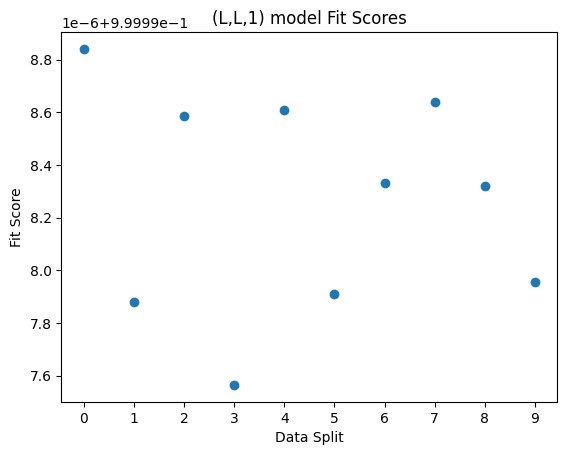

In [35]:
fits = []
for idx, mdl in enumerate(mdls):
    tmp_fit = 1 - eng.frobll1res(lwn_tns[idx], mdl) / eng.frob(lwn_tns[idx])
    fits.append(tmp_fit)
print(fits)
# plt.scatter(range(10), fits)
fits = np.asarray(fits)
plt.scatter(range(10),fits)
plt.xlabel('Data Split')
plt.ylabel('Fit Score')
plt.xticks(range(10))
plt.title('(L,L,1) model Fit Scores')


In [39]:
print(fits)

[0.99999884 0.99999788 0.99999859 0.99999757 0.99999861 0.99999791
 0.99999833 0.99999864 0.99999832 0.99999796]


TypeError: object of type 'numpy.float64' has no len()

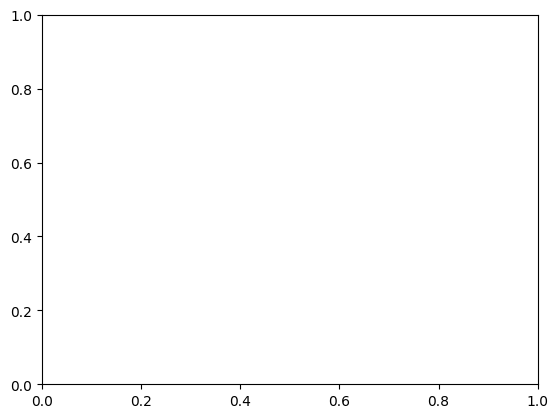

In [34]:
plt.table(fits)

## Recover 'Sources' & 'Mixing' matrices for each set

In [5]:
print(f"Number of models: {len(mdls)}")
sources = list()
mixes = list()
for idx, model in enumerate(mdls):
    tmp = ll1_tools.pack_ll1(model)
    mix = tmp[2]
    mixes.append(mix)
    src = ll1_tools.recover_sources(obs[idx], mix)
    sources.append(src)
print(f"Number of Source matrices: {len(sources)}")
print(f"Number of Mixing matrices: {len(mixes)}")

Number of models: 10
Number of Source matrices: 10
Number of Mixing matrices: 10


## Perform SVDs on transposed 'Sources' matrices as well as maximum angle between subspaces
(transpose so the left singular vectors correspond to the sources signal space)

In [6]:
# eng = matlab.engine.start_matlab()
# s = eng.genpath(tensorlab_path)
# eng.addpath(s, nargout=0)

sources_transposed = []
for src in sources:
    sources_transposed.append(src.T)
print(len(sources_transposed))

svds = []
for src in sources_transposed:
    svds.append(np.linalg.svd(src))
num_sets = len(sources)

angles_srcs = np.zeros((num_sets,num_sets))
angles_cols = np.zeros((num_sets,num_sets))
norm_of_diffs = np.zeros((num_sets,num_sets))
# cossims = np.zeros((num_sets,num_sets))
for i in range(num_sets):
    for j in range(num_sets):
        if i != j:
            angles_srcs[i,j] = eng.rad2deg(eng.subspace(sources_transposed[i], sources_transposed[j]))
            angles_cols[i,j] = eng.rad2deg(eng.subspace(svds[i][0], svds[j][0]))
            norm_of_diffs[i,j] = np.linalg.norm(sources_transposed[i] - sources_transposed[j])
            # cossims[i,j] = sklearn.metrics.pairwise.cosine_similarity(sources_transposed[i], sources_transposed[j])

10


## SVD analysis

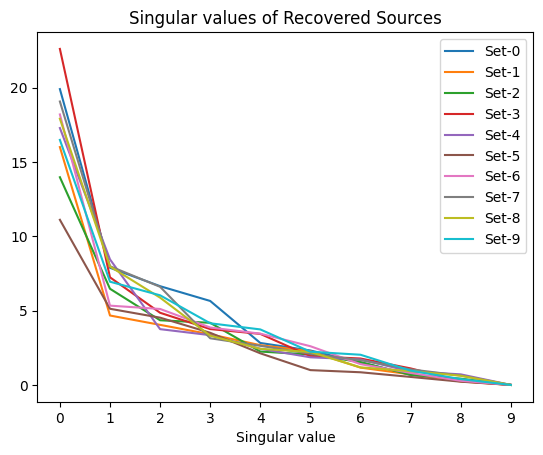

In [31]:
for i in range(len(svds)):
    plt.plot(svds[i][1], label=f"Set-{i}")

plt.xlabel('Singular value')
plt.xticks(range(len(svds)))
plt.title('Singular values of Recovered Sources')
plt.legend()

[1.99077862e+01 7.88391026e+00 6.64472817e+00 5.65054476e+00
 2.82311416e+00 2.31597889e+00 1.51486348e+00 6.83997285e-01
 3.25246094e-01 1.06541961e-15]
10


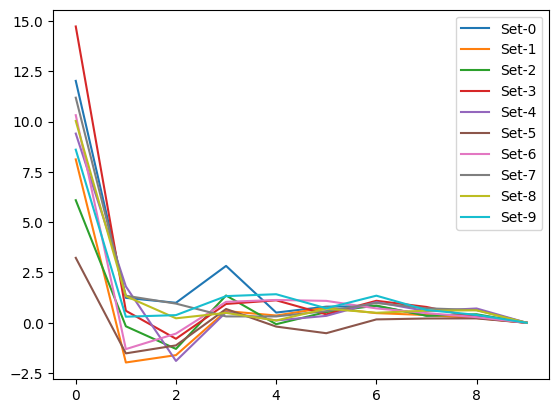

In [58]:
print(svds[0][1])
print(len(svds[0][1]))
svd_ratios = np.zeros((len(svds[0][1] - 1), 10))
svd_diffs = np.zeros((len(svds[0][1] - 1), 10))
for jdx in range(10):
    for idx in range(1,10):
        svd_ratios[idx-1, jdx] = svds[jdx][1][idx] / svds[0][1][idx-1]
        svd_diffs[idx-1, jdx] = svds[jdx][1][idx-1] - svds[0][1][idx]

for idx in range(10):
    plt.plot(svd_diffs[:, idx], label=f"Set-{idx}" )
plt.legend()

In [60]:
print(svds[1][1])
print(svd_diffs[1])


[1.60058517e+01 4.67151064e+00 4.04198614e+00 3.40618746e+00
 2.67650888e+00 2.26871562e+00 1.16458523e+00 7.09491040e-01
 2.33837698e-01 5.65784734e-16]
[ 1.23918209 -1.97321753 -0.17483658  0.59580433  1.80468073 -1.52013089
 -1.30921774  1.34420817  1.32257637  0.30161515]


## Max Principal Angle Analysis

Text(0.5, 1.0, 'Largest Principal Angle Between Recovered Sources')

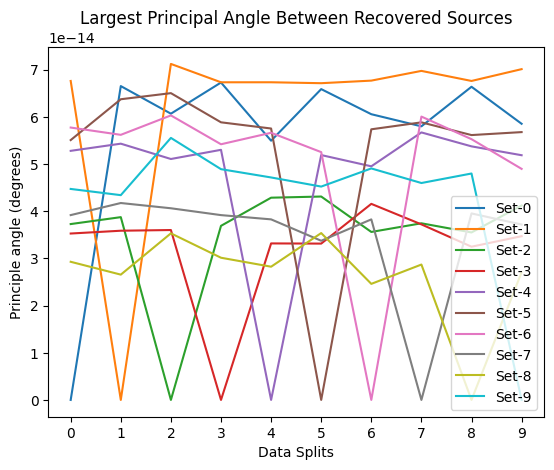

In [38]:
for i in range(angles_cols.shape[0]):
    plt.plot(angles_cols[i,:], label=f"Set-{i}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('Data Splits')
plt.ylabel('Principle angle (degrees)')
plt.title('Largest Principal Angle Between Recovered Sources')

Text(0.5, 1.0, 'Largest Principal Angle Between Recovered Sources')

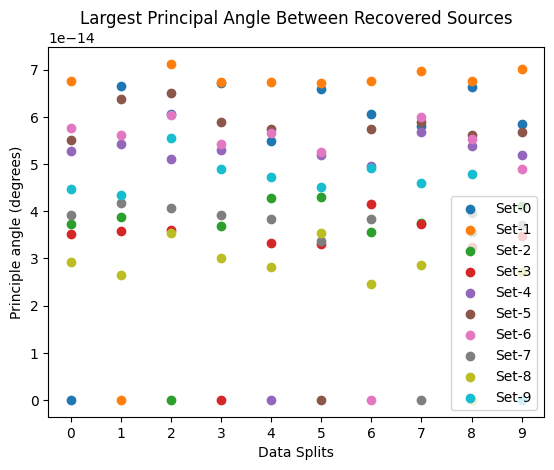

In [40]:
for i in range(angles_cols.shape[0]):
    plt.scatter(range(10),angles_cols[i,:], label=f"Set-{i}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('Data Splits')
plt.ylabel('Principle angle (degrees)')
plt.title('Largest Principal Angle Between Recovered Sources')

Text(0.5, 1.0, 'Largest Principal Angle Between Recovered Sources')

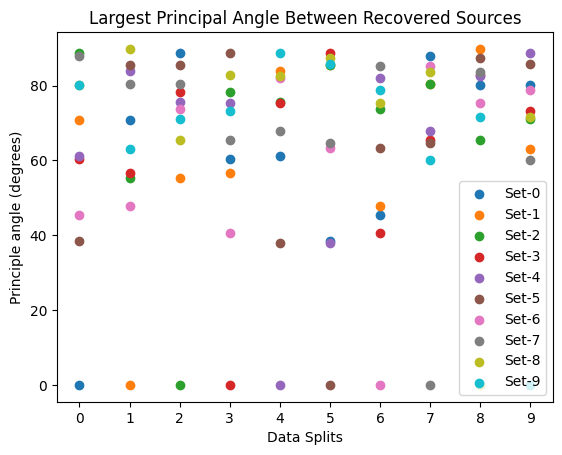

In [52]:
for i in range(angles_cols.shape[0]):
    plt.scatter(range(10),angles_srcs[i,:], label=f"Set-{i}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('Data Splits')
plt.ylabel('Principle angle (degrees)')
plt.title('Largest Principal Angle Between Recovered Sources')

## Norm of diff analysis

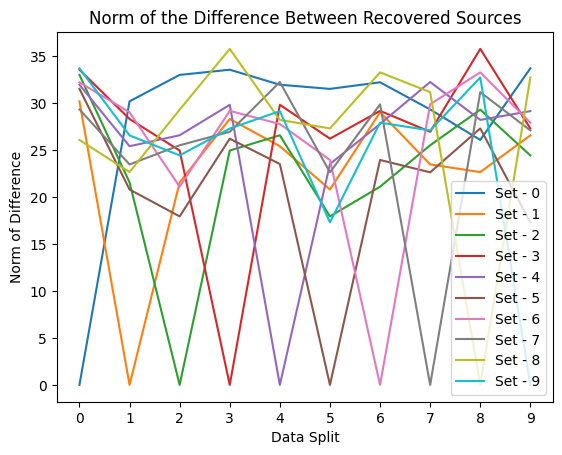

In [37]:
# basic visualization
for i in range(norm_of_diffs.shape[0]):
    plt.plot(norm_of_diffs[i,:], label=f"Set - {i}")
plt.xlabel('Data Split')
plt.ylabel('Norm of Difference')
plt.xticks(range(10))
plt.title('Norm of the Difference Between Recovered Sources')
plt.legend()

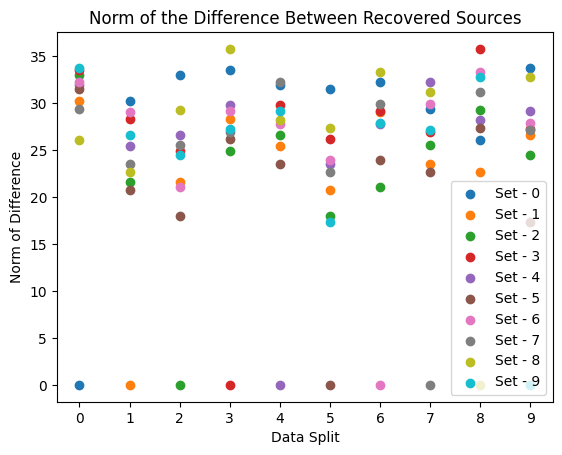

In [41]:
for i in range(norm_of_diffs.shape[0]):
    plt.scatter(range(10),norm_of_diffs[i,:], label=f"Set - {i}")
plt.xlabel('Data Split')
plt.ylabel('Norm of Difference')
plt.xticks(range(10))
plt.title('Norm of the Difference Between Recovered Sources')
plt.legend()

10
(10, 10)


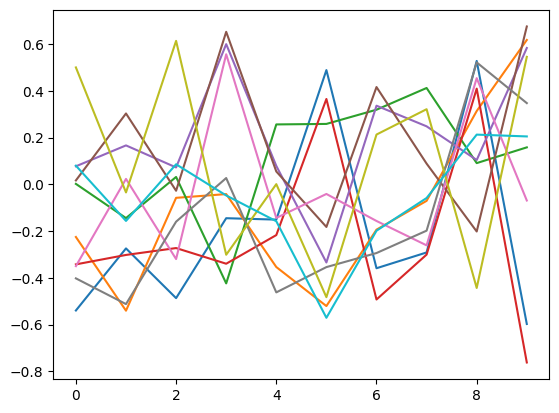

In [10]:
print(len(sources_transposed))
tmp = metrics.pairwise.cosine_similarity(sources_transposed[0], sources_transposed[1])
print(tmp.shape)
plt.plot(tmp)
# for i in range(len(sources_transposed)):
#     plt.plot(

## explore cross-correlation of sources

In [13]:
cc_01 = list()
src_0 = sources[0]
src_1 = sources[1]
for i in range(src_0.shape[0]):
    cc_01.append(np.correlate(src_0[i,:], src_1[i,:]))

print(cc_01[0])

[-41.62749158]
